# Single impurities in infinite systems

A single point defect embedded in an otherwise infinite, periodic system cannot be handled by a
plain supercell without artificially periodizing the defect. `embedding.Embedding` solves this with
a Green's function embedding technique: given the pristine, periodic Hamiltonian `h` and a modified
intracell matrix describing the defect, it gives direct access to observables of the infinite system
as perturbed by that single, non-periodic impurity, e.g. the Friedel oscillations in the LDOS
around a repulsive onsite defect on an otherwise clean chain.

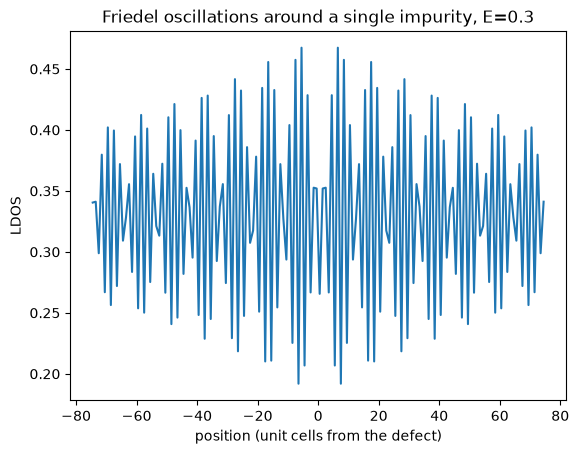

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import embedding

g = geometry.chain()
h = g.get_hamiltonian() # pristine, infinite Hamiltonian
hv = h.copy()
hv.add_onsite(lambda r: 1.0 if r[0]<0.01 else 0.0) # a single-site onsite defect
eb = embedding.Embedding(h,m=hv)

(x,y,d) = eb.get_ldos(energy=0.3,delta=1e-2,nsuper=150,nk=800,write=False)

plt.plot(x,d)
plt.xlabel("position (unit cells from the defect)") ; plt.ylabel("LDOS")
plt.title("Friedel oscillations around a single impurity, E=0.3")
plt.show()

Computing the same profile at several energies gives a map of the LDOS as a function of the
distance to the defect and of the energy. The wavelength of the Friedel oscillations changes with
energy, following the wavevector of the states of the chain at that energy, and above the top of
the band, at $E=\sqrt{4+V^2}\approx 2.24$ for the repulsive defect $V=1$, a bound state appears,
localized at the defect.

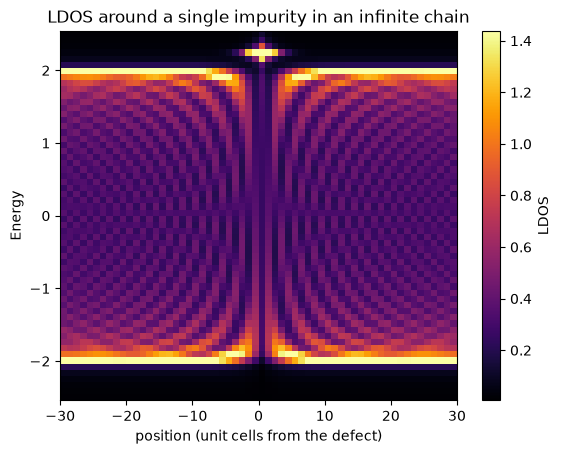

In [2]:
energies = np.linspace(-2.5,2.5,60)
ldos_map = []
for e in energies:
    (x,y,d) = eb.get_ldos(energy=e,delta=3e-2,nsuper=60,nk=400,write=False)
    ldos_map.append(d)
ldos_map = np.array(ldos_map)

plt.pcolormesh(x,energies,ldos_map,cmap="inferno",shading="auto",vmax=np.percentile(ldos_map,98))
plt.colorbar(label="LDOS")
plt.xlabel("position (unit cells from the defect)") ; plt.ylabel("Energy")
plt.title("LDOS around a single impurity in an infinite chain")
plt.show()